# 옥색 & 라벤더 — "유사색 + 비대칭 톤"을 숫자로 확인하기

영상(13:08–14:01)의 설명:

> 둘 다 차가운 계열의 **유사색** 위치에 있지만, 한쪽은 **밝고 탁한** 쪽, 다른 쪽은
> 상대적으로 **어둡고 맑은** 쪽으로 **비대칭적인 톤**이 각자의 위계를 만들고,
> 그것이 익숙함과 낯섦이 공존하는 중간 단계의 매력을 만든다.

이 문장을 세 부분으로 나눠 확인한다.

1. **유사색**: 색상각 $H$ 가 한색 영역(청록~보라)에서 비교적 가깝다.
2. **비대칭 톤**: 명도 $L$ 과 채도(크로마)가 두 색에서 **서로 반대 방향**으로 벌어져 있다.
3. 같은 "유사색"이라도 톤이 **동일**한 조합(커피브라운·올리브그린)이나
   **둘 다 어둡고 탁한** 조합(솔잎·감청)과는 다른 유형이다.

표준 라이브러리 `colorsys` + `plotly` 만 사용한다.

In [1]:
import colorsys

import plotly.graph_objects as go


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


def hex_to_rgb(hex_code: str) -> tuple[float, float, float]:
    """'#RRGGBB' -> (r, g, b) 각 0.0~1.0"""
    h = hex_code.lstrip("#")
    return tuple(int(h[i:i + 2], 16) / 255 for i in (0, 2, 4))


def analyze(hex_code: str) -> dict:
    """HSL(colorsys) + 크로마 C = max - min 을 함께 계산"""
    r, g, b = hex_to_rgb(hex_code)
    h, l, s = colorsys.rgb_to_hls(r, g, b)  # colorsys 는 (H, L, S) 순서!
    return {
        "hex": hex_code,
        "H": h * 360,          # 색상각 (도)
        "S": s * 100,          # HSL 채도 (%)
        "L": l * 100,          # HSL 명도 (%)
        "C": (max(r, g, b) - min(r, g, b)) * 100,  # 크로마 (%)
    }

## 1. 옥색과 라벤더의 HSL

colorsys 의 HSL 정의:

$$L = \frac{\max + \min}{2}, \qquad C = \max - \min, \qquad S_{HSL} = \frac{C}{1 - |2L - 1|}$$

($\max,\min$ 은 R, G, B 중 최댓값·최솟값, 모두 0~1)

색상각은 0°=빨강, 120°=초록, 240°=파랑. 대략 **150°~300°** 구간이 청록·파랑·보라의 **한색 영역**이다.

In [2]:
JADE = analyze("#00978D")      # 옥색 Benzol Green
LAVENDER = analyze("#B5B1D8")  # 라벤더 Grayish Lavender

print(f"{'색':<6}{'HEX':<10}{'H(°)':>8}{'S(%)':>8}{'L(%)':>8}{'C(%)':>8}")
for name, c in (("옥색", JADE), ("라벤더", LAVENDER)):
    print(f"{name:<6}{c['hex']:<10}{c['H']:8.1f}{c['S']:8.1f}{c['L']:8.1f}{c['C']:8.1f}")

dH = abs(JADE["H"] - LAVENDER["H"])
dH = min(dH, 360 - dH)  # 색상환에서 짧은 쪽 각도
print()
print(f"색상각 차이 ΔH = {dH:.1f}°  (보색이면 180°, 유사색은 대체로 90° 이내)")
print(f"둘 다 한색 영역(150°~300°)에 있음: {150 <= JADE['H'] <= 300 and 150 <= LAVENDER['H'] <= 300}")
print()
print(f"명도 L : 옥색 {JADE['L']:.0f}%  <  라벤더 {LAVENDER['L']:.0f}%   → 라벤더가 밝고, 옥색이 어둡다")
print(f"크로마 C: 옥색 {JADE['C']:.0f}%  >  라벤더 {LAVENDER['C']:.0f}%   → 옥색이 맑고(선명), 라벤더가 탁하다(회색기)")
print("→ 명도와 채도가 서로 반대 방향으로 벌어진 '비대칭 톤'")

색     HEX           H(°)    S(%)    L(%)    C(%)
옥색    #00978D      176.0   100.0    29.6    59.2
라벤더   #B5B1D8      246.2    33.3    77.1    15.3

색상각 차이 ΔH = 70.1°  (보색이면 180°, 유사색은 대체로 90° 이내)
둘 다 한색 영역(150°~300°)에 있음: True

명도 L : 옥색 30%  <  라벤더 77%   → 라벤더가 밝고, 옥색이 어둡다
크로마 C: 옥색 59%  >  라벤더 15%   → 옥색이 맑고(선명), 라벤더가 탁하다(회색기)
→ 명도와 채도가 서로 반대 방향으로 벌어진 '비대칭 톤'


**왜 채도를 $S_{HSL}$ 대신 크로마 $C$ 로 보는가?**

$S_{HSL} = C / (1 - |2L-1|)$ 는 분모가 $L$ 에 따라 작아지므로, 매우 어둡거나 밝은 색은
실제 색기(色氣)가 약해도 $S$ 가 부풀려진다. 예컨대 감청색 `#064F6E` 는 $S_{HSL} \approx 90\%$ 지만
눈으로는 탁한 남색이다. "맑다/탁하다"는 인상은 **크로마 $C = \max - \min$** 가 더 잘 대변한다.

## 2. 세 유형의 유사색 조합 비교

| 유형 | 조합 | 영상의 설명 |
|---|---|---|
| 유사색 + **동일 톤** | 커피브라운 `#71502F` · 올리브그린 `#788860` | 경계와 오브제가 자연스럽게 연결, 감정 진폭 억제 |
| 유사색 + **둘 다 어둡고 탁함** | 솔잎색 `#437742` · 감청색 `#064F6E` | 무게감, 수축, 사람 없는 자연 |
| 유사색 + **비대칭 톤** | 옥색 `#00978D` · 라벤더 `#B5B1D8` | 위계가 생겨 익숙함과 낯섦이 공존 |

In [3]:
PAIRS = {
    "유사색 + 동일 톤": (("커피브라운", "#71502F"), ("올리브그린", "#788860")),
    "유사색 + 둘 다 어둡고 탁함": (("솔잎색", "#437742"), ("감청색", "#064F6E")),
    "유사색 + 비대칭 톤": (("옥색", "#00978D"), ("라벤더", "#B5B1D8")),
}


def classify(a: dict, b: dict) -> str:
    """단순 규칙(예시용 임계값)으로 톤 관계를 분류"""
    mean_L = (a["L"] + b["L"]) / 2
    mean_C = (a["C"] + b["C"]) / 2
    dL, dC = abs(a["L"] - b["L"]), abs(a["C"] - b["C"])
    if mean_L < 35 and mean_C < 35:
        return "둘 다 어둡고 탁함"
    if dL < 20 and dC < 20:
        return "동일 톤"
    return "비대칭 톤"


print(f"{'조합':<28}{'ΔH(°)':>7}{'ΔL(%)':>8}{'ΔC(%)':>8}  판정")
for label, ((n1, h1), (n2, h2)) in PAIRS.items():
    a, b = analyze(h1), analyze(h2)
    dH = abs(a["H"] - b["H"])
    dH = min(dH, 360 - dH)
    print(
        f"{n1 + '·' + n2:<28}{dH:7.1f}{abs(a['L'] - b['L']):8.1f}{abs(a['C'] - b['C']):8.1f}"
        f"  {classify(a, b)}"
    )
    for n, c in ((n1, a), (n2, b)):
        print(f"    {n:<8}{c['hex']}  H={c['H']:6.1f}  L={c['L']:5.1f}  C={c['C']:5.1f}")

조합                            ΔH(°)   ΔL(%)   ΔC(%)  판정
커피브라운·올리브그린                    54.0    14.1    10.2  동일 톤
    커피브라운   #71502F  H=  30.0  L= 31.4  C= 25.9
    올리브그린   #788860  H=  84.0  L= 45.5  C= 15.7
솔잎색·감청색                        79.0    13.5    20.0  둘 다 어둡고 탁함
    솔잎색     #437742  H= 118.9  L= 36.3  C= 20.8
    감청색     #064F6E  H= 197.9  L= 22.7  C= 40.8
옥색·라벤더                         70.1    47.5    43.9  비대칭 톤
    옥색      #00978D  H= 176.0  L= 29.6  C= 59.2
    라벤더     #B5B1D8  H= 246.2  L= 77.1  C= 15.3


세 조합 모두 $\Delta H$ 는 54°~79° 로 비슷한 "유사색" 거리다. 차이는 **톤**에서 난다.

- 커피·올리브: $\Delta L$, $\Delta C$ 모두 작다 → 톤이 같아 한 덩어리로 읽힌다.
- 솔잎·감청: 두 색 모두 명도·크로마가 낮은 구석에 모여 있다 → 무겁고 탁하다.
- 옥색·라벤더: $\Delta L \approx 48$, $\Delta C \approx 44$ 로 크고, 방향이 반대다
  (밝아질수록 탁해지고, 어두워질수록 맑아진다) → 한 색이 "빛/공기", 다른 색이 "형태/무게"의 역할을
  맡는 **위계**가 생긴다. 영상은 이것을 익숙함(유사색)과 낯섦(비대칭 톤)이 공존하는 매력의 원인으로 본다.

## 3. (크로마, 명도) 평면에서 세 조합을 선으로 잇기

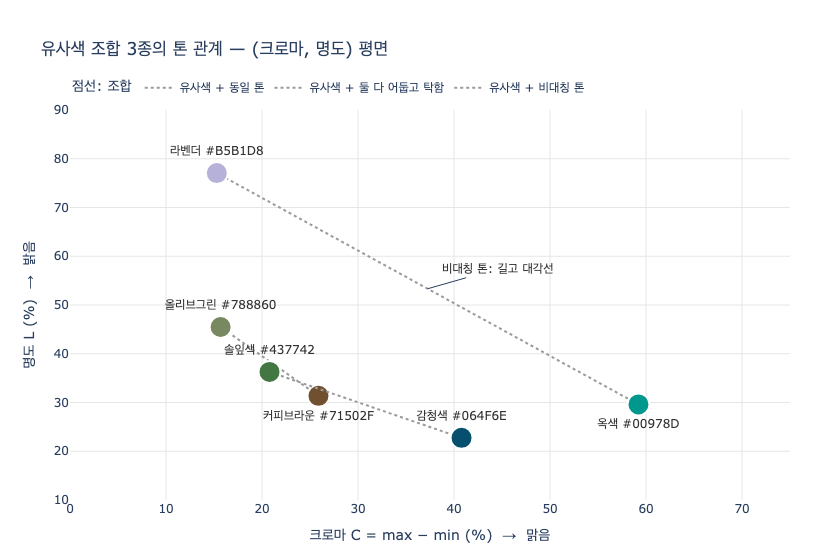

expy.png 저장 완료


In [4]:
# 라벨이 다른 마커와 겹치지 않도록 위치를 개별 지정 (기본: 첫 색 아래, 둘째 색 위)
LABEL_POS = {"솔잎색": "top center", "커피브라운": "bottom center"}

fig = go.Figure()

for label, ((n1, h1), (n2, h2)) in PAIRS.items():
    a, b = analyze(h1), analyze(h2)
    # 두 색을 잇는 선: 길이·기울기가 곧 톤 관계
    fig.add_trace(go.Scatter(
        x=[a["C"], b["C"]], y=[a["L"], b["L"]],
        mode="lines", name=label,
        line=dict(color="#9A9A9A", width=2, dash="dot"),
        hoverinfo="skip",
    ))
    # 실제 HEX 로 채운 마커 + 직접 라벨
    fig.add_trace(go.Scatter(
        x=[a["C"], b["C"]], y=[a["L"], b["L"]],
        mode="markers+text", showlegend=False,
        marker=dict(size=22, color=[h1, h2], line=dict(color="white", width=2)),
        text=[f"{n1} {h1}", f"{n2} {h2}"],
        textposition=[LABEL_POS.get(n1, "bottom center"), LABEL_POS.get(n2, "top center")],
        textfont=dict(size=12, color="#333333"),
        hovertemplate="%{text}<br>크로마 C=%{x:.1f}%<br>명도 L=%{y:.1f}%<extra></extra>",
    ))

# 옥색·라벤더 선 중앙에 설명 주석
fig.add_annotation(
    x=(JADE["C"] + LAVENDER["C"]) / 2, y=(JADE["L"] + LAVENDER["L"]) / 2,
    text="비대칭 톤: 길고 대각선", showarrow=True, arrowhead=0, ax=70, ay=-20,
    font=dict(size=12, color="#333333"),
)

fig.update_layout(
    title="유사색 조합 3종의 톤 관계 — (크로마, 명도) 평면",
    xaxis=dict(title="크로마 C = max − min (%)  →  맑음", range=[0, 75],
               gridcolor="#E6E6E6", zeroline=False),
    yaxis=dict(title="명도 L (%)  →  밝음", range=[10, 90],
               gridcolor="#E6E6E6", zeroline=False),
    plot_bgcolor="white", paper_bgcolor="white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0,
                title="점선: 조합"),
    width=820, height=560, margin=dict(l=70, r=30, t=110, b=60),
)

_show(fig)
fig.write_image("expy.png", scale=2)
print("expy.png 저장 완료")

그림 읽기:

- **옥색 → 라벤더** 선은 오른쪽 아래(맑고 어두움)에서 왼쪽 위(탁하고 밝음)로 **길게 대각선**을 그린다.
  두 색이 톤 평면의 반대편에 있어 명확한 위계가 생긴다.
- **커피브라운 → 올리브그린** 선은 짧다. 톤이 거의 같아 한 색의 두 그늘처럼 읽힌다.
- **솔잎색 → 감청색** 선은 왼쪽 아래(어둡고 탁한 구석)에서 짧게 머문다. 둘이 함께 가라앉는다.

정리: 옥색과 라벤더는 **색상(H)은 가까워 익숙하지만**, **톤(L, C)은 반대로 벌어져 낯설다**.
이 "익숙함 + 낯섦"의 동시 성립이 영상이 말하는 중간 단계의 매력이다.